# Rice Leaf Disease — Data Loading and Aggressive Augmentation

In this notebook, we will:
- Load the Rice Leaf Disease dataset
- Create training and validation datasets
- Apply aggressive augmentation
- Apply MixUp
- Reduce background bias using zoom and center cropping
- Visualize the processed training batch

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================

# 1. HYPERPARAMETERS & KAGGLE PATHS (FIXED)

# ==========================================

# TODO: Update BASE_DIR with your dataset's parent folder

BASE_DIR = '/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease'

# Pointing exactly to the train and val folders

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation') # Dataset mein ye 'val' ya 'valid' bhi ho sakta hai, path check kar lijiyega

IMAGE_SIZE = [224, 224]
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

##  Data Loading

The dataset is loaded directly from the `train` and `validation` directories.

Each subfolder represents one disease class. We use `categorical` labels because the model will work with one-hot encoded class labels.

In [19]:
# ==========================================

# 2. DATA LOADING (FIXED DIRECTORY READING)

# ==========================================

print("Loading Training Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

print("\Loading Validation Data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
print(f"\n✅ Correct Classes found: {class_names}")

<>:16: SyntaxWarning: invalid escape sequence '\L'
<>:16: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_58/856355149.py:16: SyntaxWarning: invalid escape sequence '\L'
  print("\Loading Validation Data...")


Loading Training Data...
Found 2100 files belonging to 6 classes.
\Loading Validation Data...
Found 528 files belonging to 6 classes.

✅ Correct Classes found: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


##  Advanced Augmentation — MixUp

Aggressive augmentation is used to reduce background bias.

MixUp combines two images and their corresponding labels. This helps the model learn more general features instead of memorizing specific backgrounds or image patterns.

In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("🔧 Fixing Background Bias with Aggressive Augmentation...")

# ==========================================

# 3. ADVANCED AUGMENTATION: ZOOM + MIXUP

# ==========================================

def mixup(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]
    gamma_1 = tf.random.gamma(shape=[batch_size, 1, 1, 1], alpha=alpha)
    gamma_2 = tf.random.gamma(shape=[batch_size, 1, 1, 1], alpha=alpha)
    l = gamma_1 / (gamma_1 + gamma_2)

    indices = tf.random.shuffle(tf.range(batch_size))
    images_shuffled = tf.gather(images, indices)
    labels_shuffled = tf.gather(labels, indices)

    images_mixed = l * images + (1.0 - l) * images_shuffled
    l_labels = tf.reshape(l, [batch_size, 1])
    labels_mixed = l_labels * labels + (1.0 - l_labels) * labels_shuffled

    return images_mixed, labels_mixed

🔧 Fixing Background Bias with Aggressive Augmentation...


## Aggressive Data Augmentation

The augmentation pipeline applies:

- Random Zoom
- Horizontal and vertical flipping
- Random rotation

The objective is to force the model to focus more on the rice leaf rather than the surrounding background.

In [21]:
# 🚨 THE FIX: Aggressive zoom to cut out the background

data_augmentation = tf.keras.Sequential([
    # Negative values zoom IN. Zooming 30% to 50% forces focus on the leaf.
    tf.keras.layers.RandomZoom(
        height_factor=(-0.3, -0.5),
        width_factor=(-0.3, -0.5),
        fill_mode='nearest'
    ),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

##  Preparing Training Dataset

The training dataset receives:
1. Data augmentation
2. MixUp
3. Prefetching

Prefetching helps improve the data pipeline performance during model training.

In [22]:
def prepare_train_dataset(ds):
    ds = ds.map(
        lambda x, y: (data_augmentation(x, training=True), y),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.map(mixup, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

## Preparing Validation Dataset

Validation images are not passed through MixUp or random augmentation.

Instead, a center crop is applied and then the image is resized back to `224 × 224`.

This approximately matches the zoom effect used during training.

In [23]:
def prepare_val_dataset(ds):
    # 🚨 THE FIX: Center crop validation data to match the zoom effect (approx 30% crop)
    crop_layer = tf.keras.layers.CenterCrop(height=156, width=156)
    resize_layer = tf.keras.layers.Resizing(224, 224)

    ds = ds.map(
        lambda x, y: (resize_layer(crop_layer(x)), y),
        num_parallel_calls=AUTOTUNE
    )
    return ds.prefetch(buffer_size=AUTOTUNE)

##  Create Optimized Training and Validation Datasets

The functions defined above are now applied to the original training and validation datasets.

In [24]:
train_ds_optimized = prepare_train_dataset(train_ds)
val_ds_optimized = prepare_val_dataset(val_ds)

##  Visualization

Before training the model, we visualize a batch of augmented images.

This helps verify whether:
- The images are being cropped correctly
- Augmentation is working
- MixUp is working
- The background is reduced
- The labels are correctly associated with the images

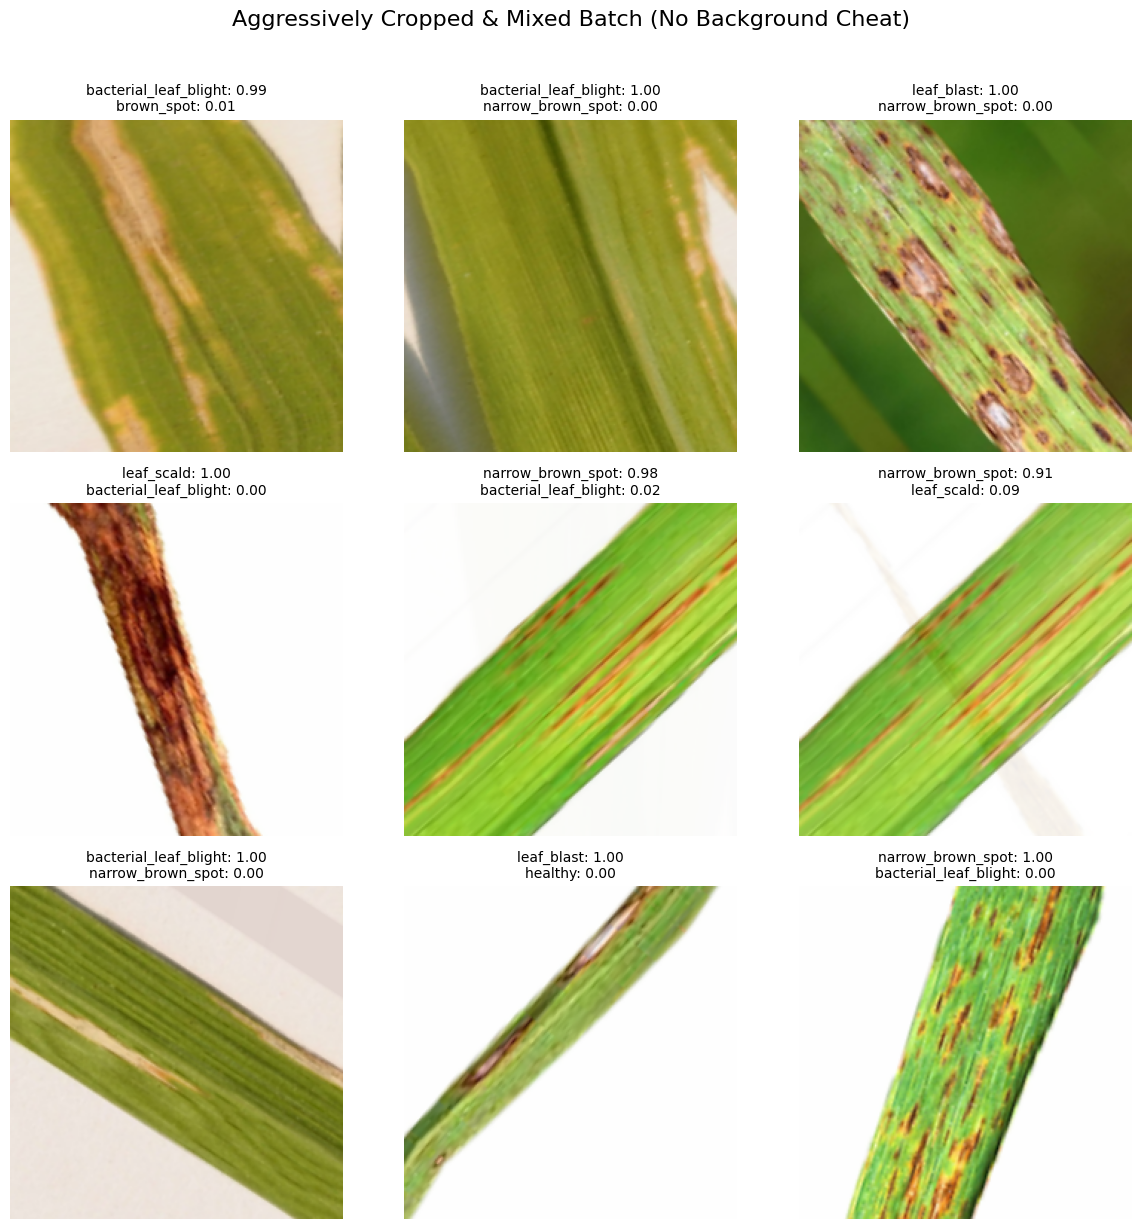

In [ ]:
# 4. VISUALIZATION (Verify the Fix)

def show_batch(image_batch, label_batch):
    plt.figure(figsize=(12, 12))
    for n in range(min(9, len(image_batch))):
        ax = plt.subplot(3, 3, n + 1)
        img = image_batch[n].numpy().astype("uint8")
        plt.imshow(img)
        label_arr = label_batch[n].numpy()
        top_2_idx = np.argsort(label_arr)[-2:][::-1]

        title = f"{class_names[top_2_idx[0]]}: {label_arr[top_2_idx[0]]:.2f}\n" \
                f"{class_names[top_2_idx[1]]}: {label_arr[top_2_idx[1]]:.2f}"
        plt.title(title, fontsize=10)
        plt.axis("off")

    plt.suptitle(
        "Aggressively Cropped & Mixed Batch (No Background Cheat)",
        fontsize=16,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

image_batch, label_batch = next(iter(train_ds_optimized))
show_batch(image_batch, label_batch)

###  Load Pre-trained Base Model
Loads the DenseNet121 model without the top layer and freezes its weights for the initial feature extraction phase.

In [ ]:
import tensorflow as tf
# We load the model without the top classification layer
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# Freeze the base model for Phase 1 of training (Feature Extraction)
base_model.trainable = False

###  Custom Classification Head
Builds a robust custom head using Global Average Pooling, Batch Normalization, and a 5-branch Multi-Sample Dropout architecture to reduce overfitting.

In [27]:
# ==========================================
# CUSTOM SOTA CLASSIFICATION HEAD
# ==========================================
inputs = tf.keras.Input(shape=(224, 224, 3))

# Note: training=False is CRUCIAL here so base model's internal BatchNorm 
# layers don't update their moving averages during feature extraction.
x = base_model(inputs, training=False)

# Global Average Pooling
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Batch Normalization (User's choice)
x = tf.keras.layers.BatchNormalization()(x)

# Multi-Sample Dropout (User's choice: 5 parallel layers)
# We will create 5 parallel branches with Dropout -> Dense(6)
dropout_rate = 0.3
num_classes = 6 # We found 6 classes in Step 1
fc_outputs = []

for i in range(5):
    # Each branch gets a unique dropout mask automatically
    branch_drop = tf.keras.layers.Dropout(rate=dropout_rate, name=f'multi_dropout_{i}')(x)
    # Output layer for each branch (without softmax yet)
    branch_dense = tf.keras.layers.Dense(num_classes, name=f'dense_branch_{i}')(branch_drop)
    fc_outputs.append(branch_dense)

# Average the logits from all 5 branches
averaged_logits = tf.keras.layers.Average(name='average_ensemble')(fc_outputs)

# Apply final Softmax activation
outputs = tf.keras.layers.Activation('softmax', name='final_softmax')(averaged_logits)

###  Compile Model
Combines the inputs and outputs into the final model, then compiles it using the Adam optimizer and categorical cross-entropy loss.

In [28]:

model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Using Adam optimizer with a standard learning rate for the initial head training
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy', # Because we are using MixUp (one-hot encoded labels)
    metrics=['accuracy']
)

print("✅ Custom SOTA DenseNet121 Model Created Successfully!")
model.summary()

✅ Custom SOTA DenseNet121 Model Created Successfully!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_4[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_0     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_1     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_2     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_3     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_4     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_0      │ (None, 6)         │      6,150 │ multi_dropout_0[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_1      │ (None, 6)         │      6,150 │ multi_dropout_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_2      │ (None, 6)         │      6,150 │ multi_dropout_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_3      │ (None, 6)         │      6,150 │ multi_dropout_3[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_4      │ (None, 6)         │      6,150 │ multi_dropout_4[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_ensemble    │ (None, 6)         │          0 │ dense_branch_0[0… │
│ (Average)           │                   │            │ dense_branch_1[0… │
│                     │                   │            │ dense_branch_2[0… │
│                     │                   │            │ dense_branch_3[0… │
│                     │                   │            │ dense_branch_4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_softmax       │ (None, 6)         │          0 │ average_ensemble

 Total params: 7,072,350 (26.98 MB)

 Trainable params: 32,798 (128.12 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

### Setup Callbacks
Initializes standard adaptive callbacks for the training process. This includes saving the best model weights, reducing the learning rate if the validation loss plateaus, and stopping training early to prevent overfitting.

In [29]:
import tensorflow as tf

# Setup Callbacks (Standard Adaptive)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    save_best_only=True,
    monitor="val_accuracy", 
    mode="max",
    verbose=1
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

callbacks_list = [checkpoint_cb, reduce_lr_cb, early_stopping_cb]

### Train Custom Head
Executes the initial training phase to train the custom classification head for a set number of epochs while the base model remains completely frozen.

In [30]:
# Training The Custom Head
EPOCHS = 25

print("🚀 Starting Feature Extraction Training...")

history = model.fit(
    train_ds_optimized,
    validation_data=val_ds_optimized,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

print("✅ Training Completed!")

🚀 Starting Feature Extraction Training...
Epoch 1/25
 1/66 ━━━━━━━━━━━━━━━━━━━━ 40:28 37s/step - accuracy: 0.1250 - loss: 1.9257

I0000 00:00:1786479517.258031     136 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.4800 - loss: 1.3896
Epoch 1: val_accuracy improved from None to 0.44508, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 101s 979ms/step - accuracy: 0.5890 - loss: 1.1815 - val_accuracy: 0.4451 - val_loss: 1.8705 - learning_rate: 0.0010
Epoch 2/25
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.6853 - loss: 1.0250
Epoch 2: val_accuracy improved from 0.44508 to 0.66667, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.6976 - loss: 0.9792 - val_accuracy: 0.6667 - val_loss: 1.0621 - learning_rate: 0.0010
Epoch 3/25
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.7220 - loss: 0.8888
Epoch 3: val_accuracy improved from 0.66667 to 0.73485, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 298ms/step - accu

### Generate Confusion Matrix
Resets the validation data generator, calculates predictions, and visualizes the model's performance using a confusion matrix and a detailed classification report.

Extracting true labels from validation dataset...
Generating predictions on validation data...
17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 887ms/step


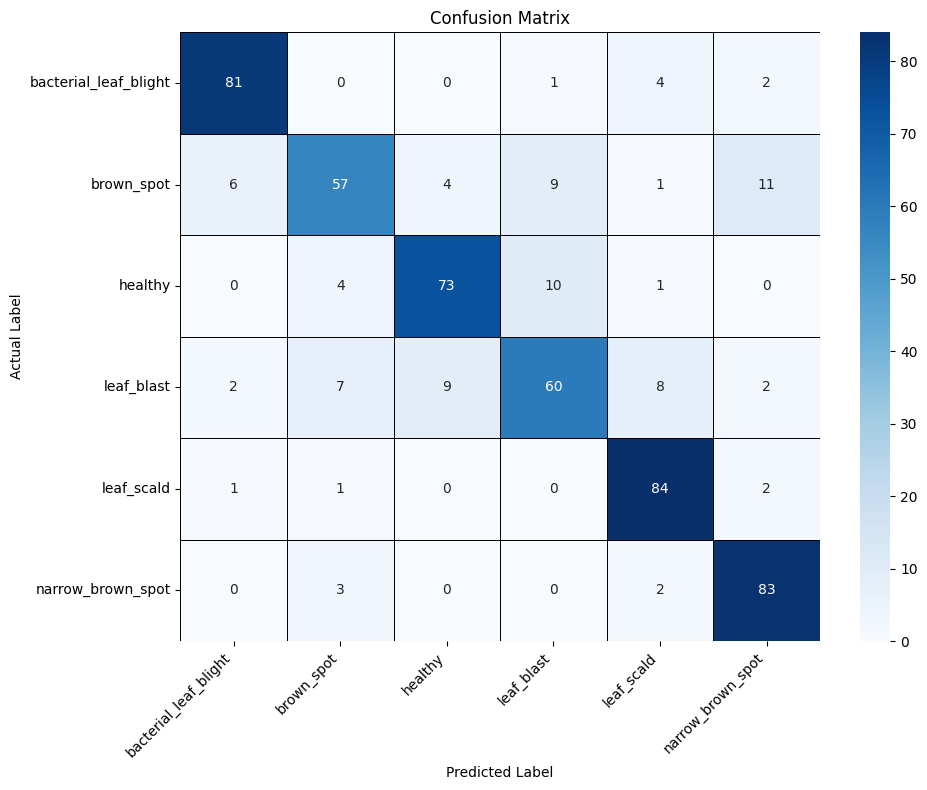


Classification Report:

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.90      0.92      0.91        88
           brown_spot       0.79      0.65      0.71        88
              healthy       0.85      0.83      0.84        88
           leaf_blast       0.75      0.68      0.71        88
           leaf_scald       0.84      0.95      0.89        88
    narrow_brown_spot       0.83      0.94      0.88        88

             accuracy                           0.83       528
            macro avg       0.83      0.83      0.83       528
         weighted avg       0.83      0.83      0.83       528



In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Extracting true labels from validation dataset...")
y_true = []
for images, labels in val_ds_optimized:
    # Assuming label_mode='categorical', we use argmax to get the class index
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

print("Generating predictions on validation data...")
predictions = model.predict(val_ds_optimized, verbose=1)
y_pred = np.argmax(predictions, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            linewidths=0.5, linecolor='black')

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

### Pre Fine-Tuning Accuracy
Extracts metrics from the first training phase and plots the training versus validation accuracy before any fine-tuning was applied.

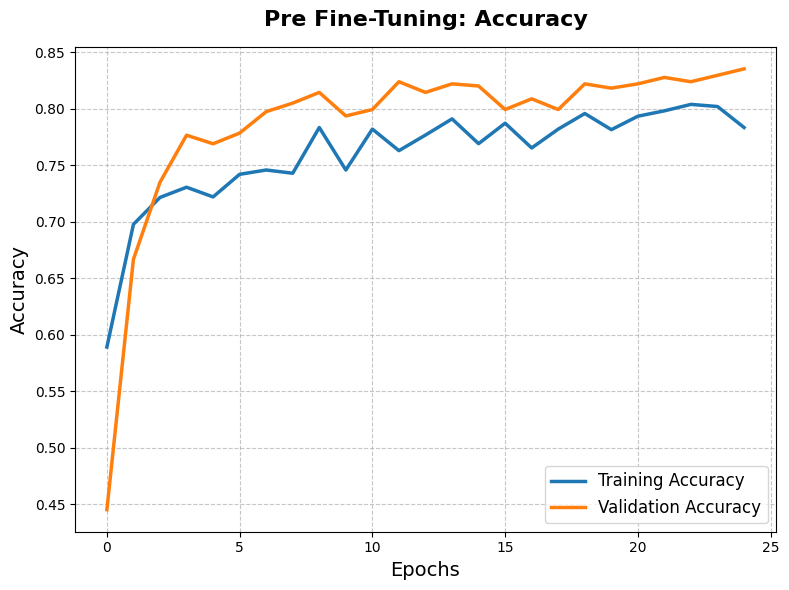

In [46]:
import matplotlib.pyplot as plt

# Humne training 'history' variable me save ki thi
acc_phase1 = history.history['accuracy']
val_acc_phase1 = history.history['val_accuracy']
epochs_phase1 = range(len(acc_phase1))

plt.figure(figsize=(8, 6))
plt.plot(epochs_phase1, acc_phase1, label='Training Accuracy', linewidth=2.5)
plt.plot(epochs_phase1, val_acc_phase1, label='Validation Accuracy', linewidth=2.5)
plt.legend(loc='lower right', fontsize=12)
plt.title('Pre Fine-Tuning: Accuracy', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Pre Fine-Tuning Loss
Visualizes the training versus validation loss from the initial feature extraction phase to check for early convergence or overfitting.

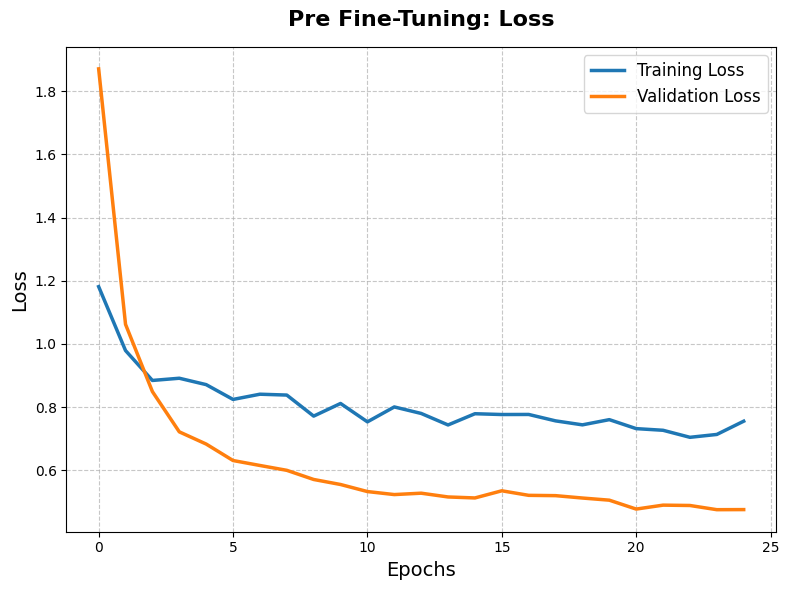

In [48]:
loss_phase1 = history.history['loss']
val_loss_phase1 = history.history['val_loss']

plt.figure(figsize=(8, 6))
plt.plot(epochs_phase1, loss_phase1, label='Training Loss', linewidth=2.5)
plt.plot(epochs_phase1, val_loss_phase1, label='Validation Loss', linewidth=2.5)
plt.legend(loc='upper right', fontsize=12)
plt.title('Pre Fine-Tuning: Loss', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Unfreeze and Recompile Model
Unfreezes the base model and recompiles it using the SGD optimizer with momentum and a very small learning rate to safely fine-tune the weights.

In [37]:
import tensorflow as tf

# Unfreeze the base model
base_model.trainable = True

print(f"Base model trainable status: {base_model.trainable}")

# Recompile with SGD and momentum
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

print("\n✅ Model recompiled for Fine-Tuning!")
model.summary()

Base model trainable status: True

✅ Model recompiled for Fine-Tuning!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_4[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_0     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_1     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_2     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_3     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_dropout_4     │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_0      │ (None, 6)         │      6,150 │ multi_dropout_0[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_1      │ (None, 6)         │      6,150 │ multi_dropout_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_2      │ (None, 6)         │      6,150 │ multi_dropout_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_3      │ (None, 6)         │      6,150 │ multi_dropout_3[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_branch_4      │ (None, 6)         │      6,150 │ multi_dropout_4[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_ensemble    │ (None, 6)         │          0 │ dense_branch_0[0… │
│ (Average)           │                   │            │ dense_branch_1[0… │
│                     │                   │            │ dense_branch_2[0… │
│                     │                   │            │ dense_branch_3[0… │
│                     │                   │            │ dense_branch_4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_softmax       │ (None, 6)         │          0 │ average_ensemble

 Total params: 7,072,350 (26.98 MB)

 Trainable params: 6,986,654 (26.65 MB)

 Non-trainable params: 85,696 (334.75 KB)

### Setup Fine-Tuning Callbacks
Configures adaptive callbacks tailored for the fine-tuning phase, saving a separate model checkpoint and using a more sensitive learning rate reduction strategy.

In [38]:
# Setup Callbacks for Fine-Tuning
checkpoint_cb_phase2 = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model_phase2.keras", 
    save_best_only=True,
    monitor="val_accuracy", 
    mode="max",
    verbose=1
)

reduce_lr_cb_phase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,      
    min_lr=1e-7,
    verbose=1
)

early_stopping_cb_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks_phase2 = [checkpoint_cb_phase2, reduce_lr_cb_phase2, early_stopping_cb_phase2]

### Execute Fine-Tuning
Runs the second phase of training to gently fine-tune the entire model architecture.

In [39]:
# Training (Fine-Tuning)
EPOCHS_PHASE_2 = 25

print("\n🚀 Starting Fine-Tuning...")

history_phase2 = model.fit(
    train_ds_optimized,
    validation_data=val_ds_optimized,
    epochs=EPOCHS_PHASE_2,
    callbacks=callbacks_phase2
)

print("✅ Fine-Tuning Completed!")


🚀 Starting Fine-Tuning...
Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3530 - loss: 1.6839   
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.4714 - loss: 1.4274 - val_accuracy: 0.1667 - val_loss: 4.5259 - learning_rate: 1.0000e-04
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.6316 - loss: 1.0532
Epoch 2: val_accuracy improved from 0.16667 to 0.33144, saving model to best_model_phase2.keras

Epoch 2: finished saving model to best_model_phase2.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 334ms/step - accuracy: 0.6624 - loss: 0.9934 - val_accuracy: 0.3314 - val_loss: 2.5159 - learning_rate: 1.0000e-04
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7306 - loss: 0.8913
Epoch 3: val_accuracy improved from 0.33144 to 0.39394, saving model to best_model_phase2.keras

Epoch 3: finished sav

### Post Fine-Tuning Accuracy
Plots the training and validation accuracy specifically for the second phase, showing how unfreezing the base model improved performance.

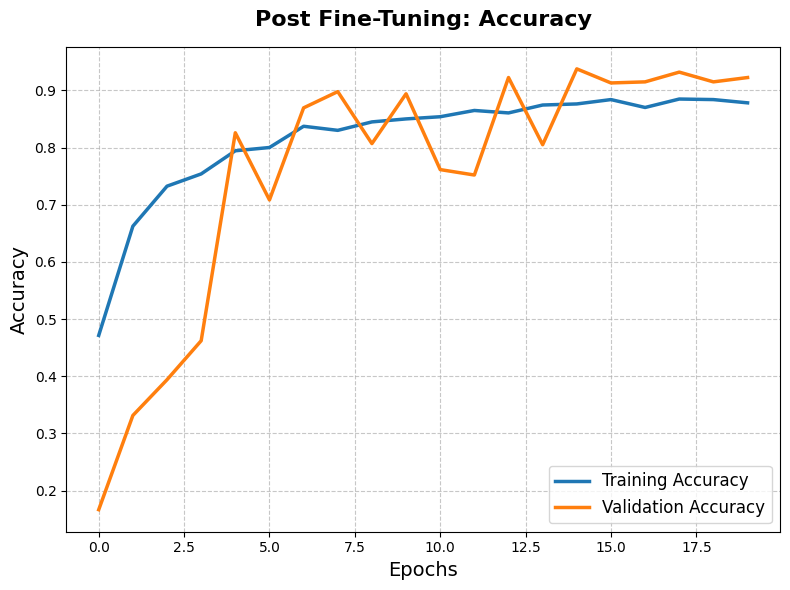

In [47]:
acc_phase2 = history_phase2.history['accuracy']
val_acc_phase2 = history_phase2.history['val_accuracy']
epochs_phase2 = range(len(acc_phase2))

plt.figure(figsize=(8, 6))
plt.plot(epochs_phase2, acc_phase2, label='Training Accuracy', linewidth=2.5)
plt.plot(epochs_phase2, val_acc_phase2, label='Validation Accuracy', linewidth=2.5)
plt.legend(loc='lower right', fontsize=12)
plt.title('Post Fine-Tuning: Accuracy', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Post Fine-Tuning Loss
Visualizes the training and validation loss during the fine-tuning phase to monitor how smoothly the model adapts to the new learning rate.

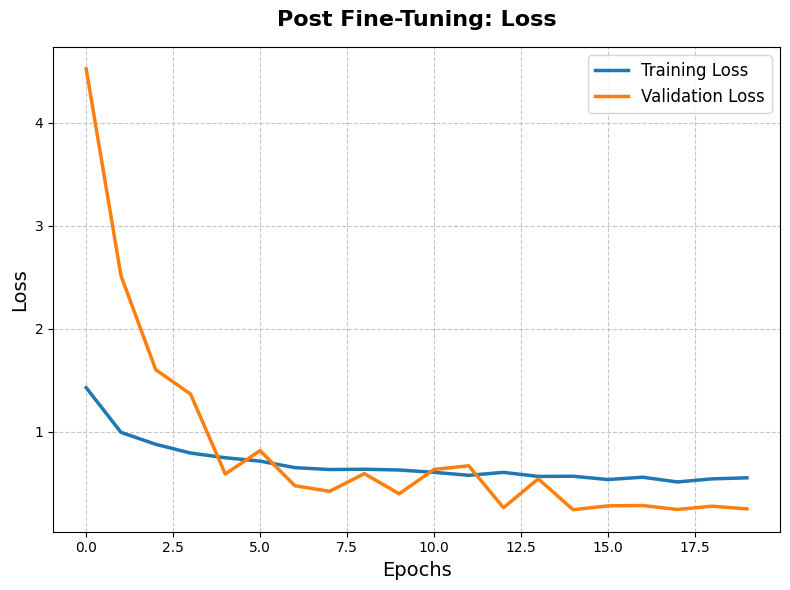

In [49]:
loss_phase2 = history_phase2.history['loss']
val_loss_phase2 = history_phase2.history['val_loss']

plt.figure(figsize=(8, 6))
plt.plot(epochs_phase2, loss_phase2, label='Training Loss', linewidth=2.5)
plt.plot(epochs_phase2, val_loss_phase2, label='Validation Loss', linewidth=2.5)
plt.legend(loc='upper right', fontsize=12)
plt.title('Post Fine-Tuning: Loss', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### comparative graph

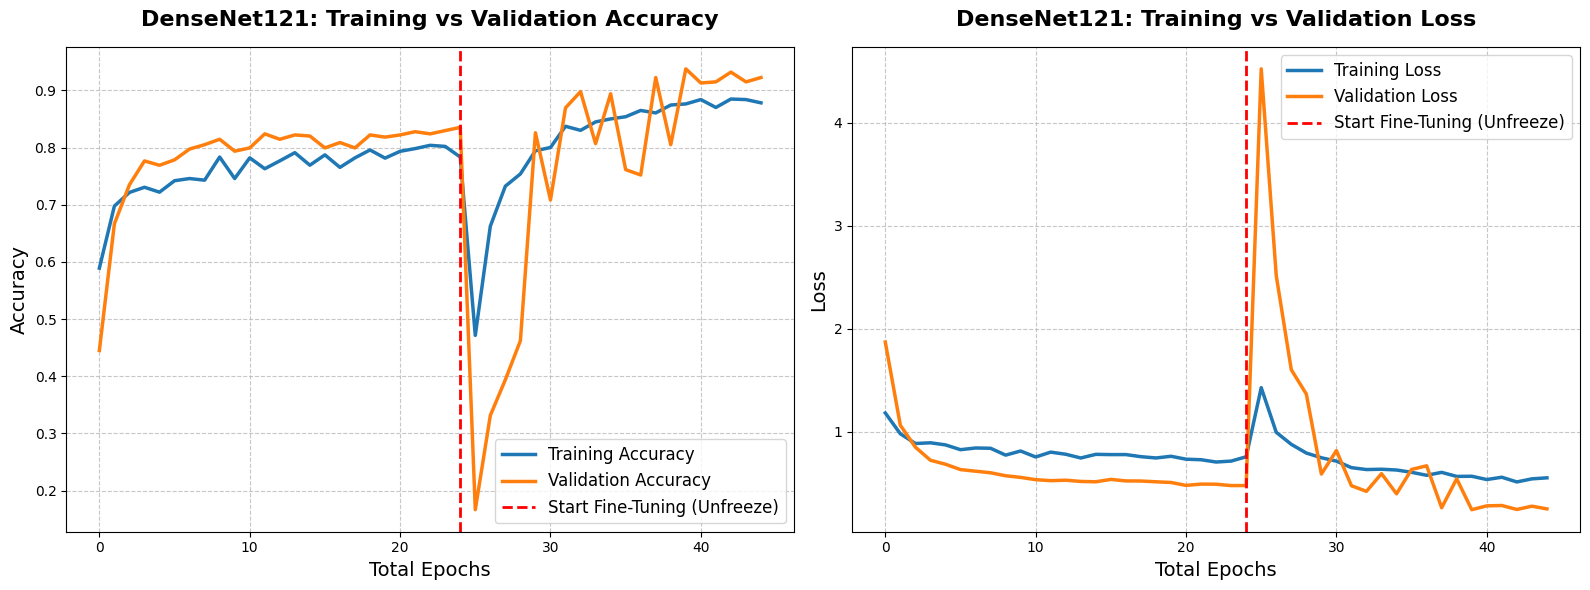

In [53]:
import matplotlib.pyplot as plt

# 1. COMBINING TRAINING HISTORIES
# 'history' aapke phase 1 ka variable hai, aur 'history_phase2' fine-tuning ka
acc = history.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history.history['loss'] + history_phase2.history['loss']
val_loss = history.history['val_loss'] + history_phase2.history['val_loss']

epochs_range = range(len(acc))

# Dynamic tareeke se phase 1 ke epochs nikalna (Early stopping ke hisaab se)
phase1_epochs_completed = len(history.history['accuracy'])

# 2. PLOTTING THE JOURNEY
plt.figure(figsize=(16, 6))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2.5)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2.5)
# Vertical line to show where Fine-Tuning started
plt.axvline(x=phase1_epochs_completed - 1, color='red', linestyle='--', linewidth=2, label='Start Fine-Tuning (Unfreeze)')
plt.legend(loc='lower right', fontsize=12)
plt.title('DenseNet121: Training vs Validation Accuracy', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2.5)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2.5)
plt.axvline(x=phase1_epochs_completed - 1, color='red', linestyle='--', linewidth=2, label='Start Fine-Tuning (Unfreeze)')
plt.legend(loc='upper right', fontsize=12)
plt.title('DenseNet121: Training vs Validation Loss', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Generate Confusion Matrix afert Fine- tune
Resets the validation data generator, calculates predictions, and visualizes the model's performance using a confusion matrix and a detailed classification report.

🔍 Running predictions on Validation Data...
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 905ms/step

📊 Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.94      1.00      0.97        88
           brown_spot       0.84      0.90      0.87        88
              healthy       0.94      0.94      0.94        88
           leaf_blast       0.92      0.82      0.87        88
           leaf_scald       1.00      0.97      0.98        88
    narrow_brown_spot       0.99      1.00      0.99        88

             accuracy                           0.94       528
            macro avg       0.94      0.94      0.94       528
         weighted avg       0.94      0.94      0.94       528



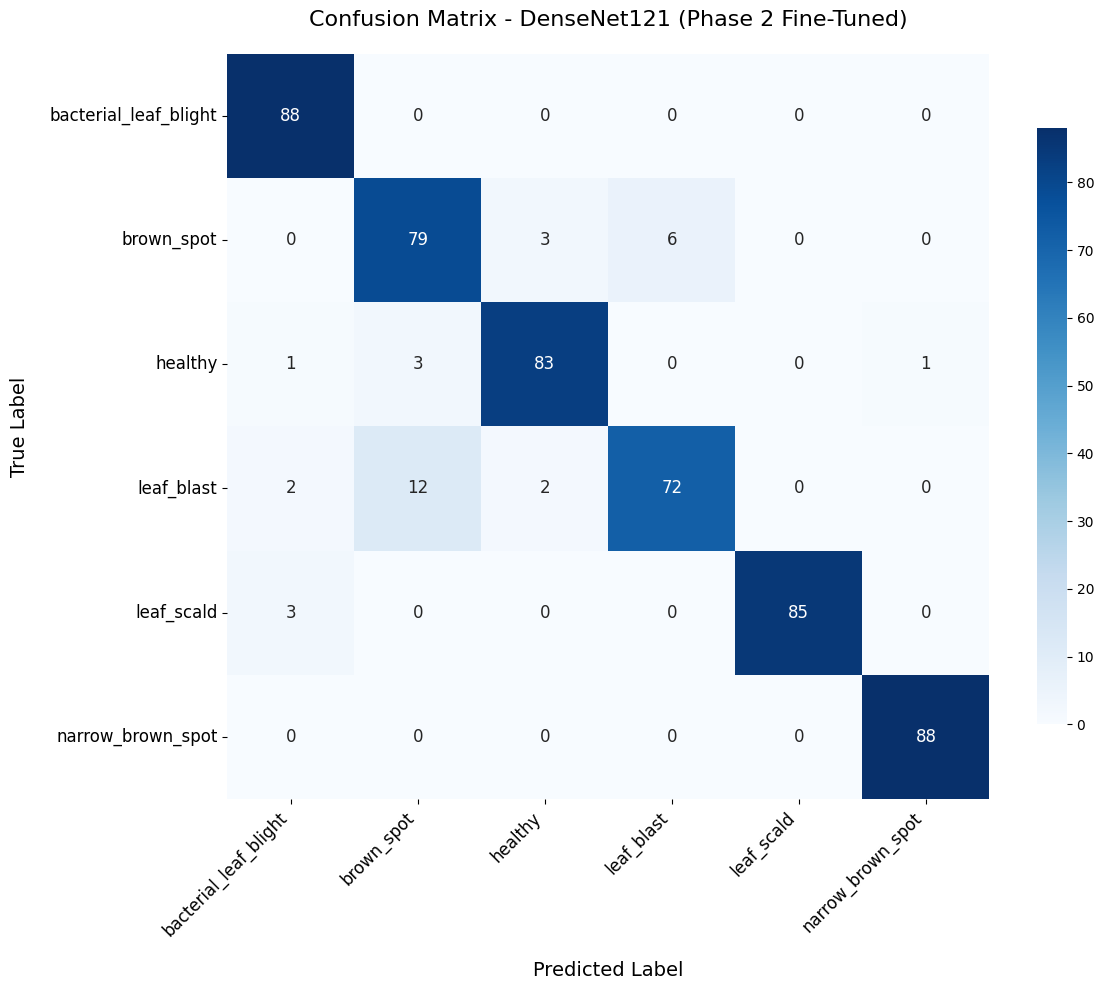

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("🔍 Running predictions on Validation Data...")

# Kaggle tf.data se directly predictions nikalna
y_pred_probs = model.predict(val_ds_optimized)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels extract karna (MixUp ke one-hot encoded format se wapas integer format mein)
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for images, labels in val_ds_optimized], axis=0)

# ==========================================
# 1. CLASSIFICATION REPORT
# ==========================================
print("\n📊 Classification Report:")
# Using class_names defined in Step 1
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# ==========================================
# 2. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': .8}, annot_kws={"size": 12})

plt.title('Confusion Matrix - DenseNet121 (Phase 2 Fine-Tuned)', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=14, labelpad=15)
plt.ylabel('True Label', fontsize=14, labelpad=15)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

### Install LIME
Installs the LIME library required for generating local interpretable model-agnostic explanations. Run this cell first if LIME is not already installed in your Kaggle environment.

In [54]:
!pip install lime

### Recover Dataset and Class Names
Imports necessary libraries, sets up the directory paths, and reloads the validation dataset to retrieve the images and class names.

In [55]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

BASE_DIR = '/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease' 
VAL_DIR = os.path.join(BASE_DIR, 'validation')
IMAGE_SIZE = [224, 224]
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)
class_names = val_ds.class_names

val_ds_optimized = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 528 files belonging to 6 classes.


### Recover Trained Model
Loads the saved weights of the model that was fine-tuned in the previous phase.

In [56]:
model = tf.keras.models.load_model('best_model_phase2.keras')

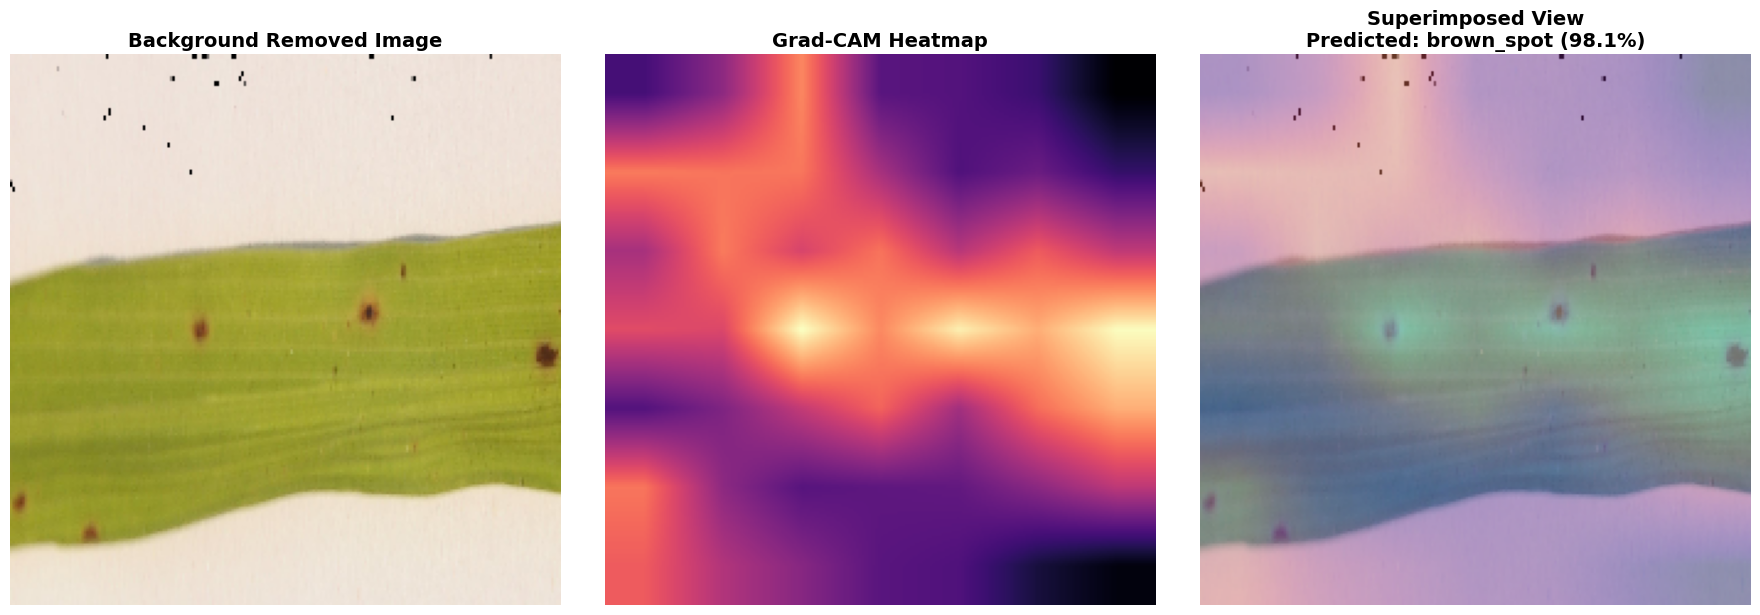

In [90]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Resize the background-removed image to match the model's expected input shape
processed_img = cv2.resize(bg_removed_img, (224, 224))
img_tensor = tf.expand_dims(processed_img, 0)

# Redefine the fixed Grad-CAM function with correct layer names
densenet_base = model.get_layer('densenet121')
last_conv_layer_name = 'relu'

grad_base_model = tf.keras.Model(
    inputs=densenet_base.inputs,
    outputs=[densenet_base.get_layer(last_conv_layer_name).output, densenet_base.output]
)

def generate_grad_cam_fixed(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = grad_base_model(img_array)
        tape.watch(conv_outputs)

        x = model.get_layer('global_average_pooling2d_1')(base_outputs)
        x = model.get_layer('batch_normalization_1')(x)

        fc_outputs = []
        for i in range(5):
            d = model.get_layer(f'multi_dropout_{i}')(x, training=False)
            fc = model.get_layer(f'dense_branch_{i}')(d)
            fc_outputs.append(fc)

        avg = model.get_layer('average_ensemble')(fc_outputs)
        preds = model.get_layer('final_softmax')(avg)

        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy(), preds[0].numpy(), top_pred_index.numpy()

# Generate the heatmap
heatmap, preds, pred_idx = generate_grad_cam_fixed(img_tensor)

# Prepare for visualization
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_magma = np.uint8(255 * heatmap_resized)
heatmap_magma_color = cv2.applyColorMap(heatmap_magma, cv2.COLORMAP_MAGMA)

# Superimpose the heatmap onto the background-removed image
superimposed_img = cv2.addWeighted(processed_img, 0.6, heatmap_magma_color, 0.4, 0)

# Plot the results
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(processed_img)
plt.title("Background Removed Image", fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap='magma')
plt.title("Grad-CAM Heatmap", fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title(f"Superimposed View\nPredicted: {class_names[pred_idx]} ({preds[pred_idx]*100:.1f}%)", fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

### Predict and Compare Two Images
Accepts two specific image paths, processes them, and displays each image alongside a bar chart showing the model's exact confidence percentage for every single class.

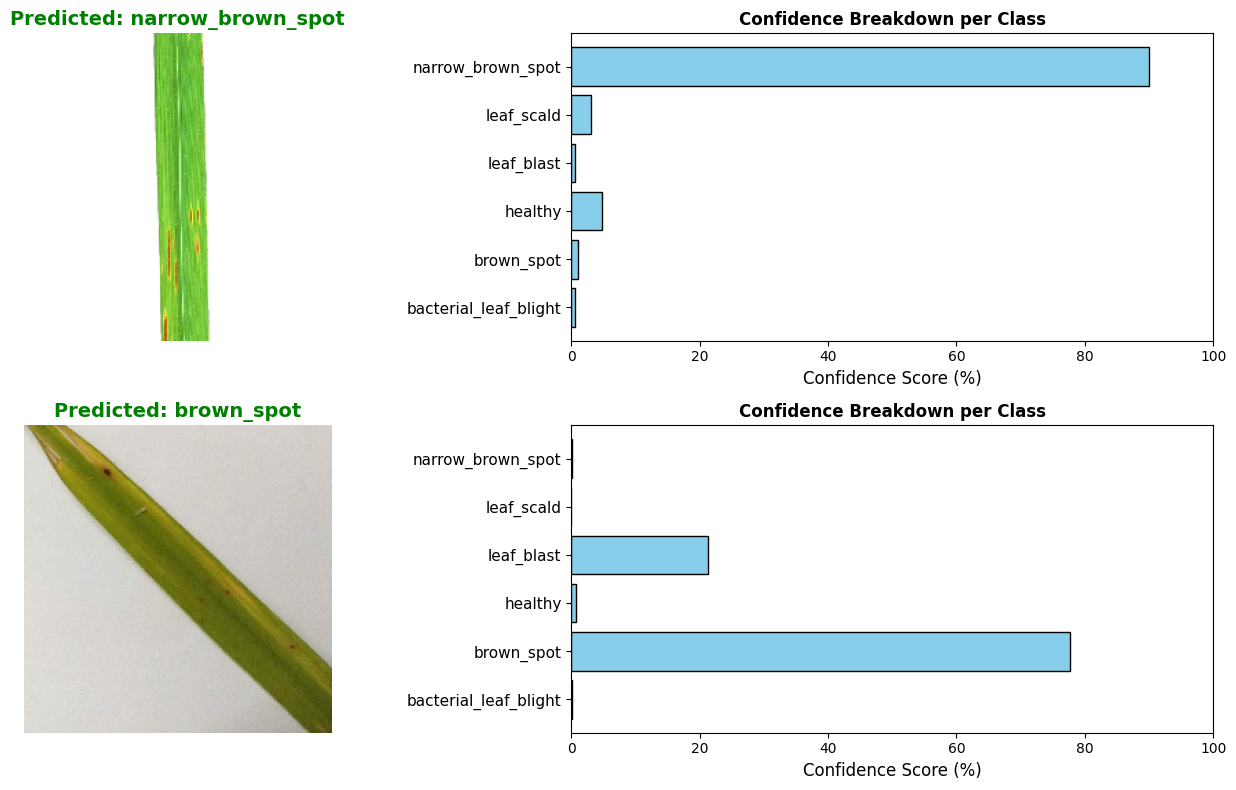

In [60]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH_1 = '/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/train/narrow_brown_spot/narrow_brown (10).jpg'
IMAGE_PATH_2 = '/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation/brown_spot/brown_val (11).jpg'

image_paths = [IMAGE_PATH_1, IMAGE_PATH_2]

plt.figure(figsize=(14, 8))

for i, path in enumerate(image_paths):
    img = tf.keras.utils.load_img(path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = tf.expand_dims(img_array, 0)
    
    predictions = model.predict(img_batch, verbose=0)[0]
    predicted_class_idx = np.argmax(predictions)
    predicted_class_name = class_names[predicted_class_idx]
    
    plt.subplot(2, 2, i * 2 + 1)
    plt.imshow(img_array.astype("uint8"))
    plt.title(f"Predicted: {predicted_class_name}", fontsize=14, fontweight='bold', color='green')
    plt.axis("off")
    
    plt.subplot(2, 2, i * 2 + 2)
    y_positions = np.arange(len(class_names))
    plt.barh(y_positions, predictions * 100, color='skyblue', edgecolor='black')
    plt.yticks(y_positions, class_names, fontsize=11)
    plt.xlabel('Confidence Score (%)', fontsize=12)
    plt.title('Confidence Breakdown per Class', fontsize=12, fontweight='bold')
    plt.xlim(0, 100)

plt.tight_layout()
plt.show()